# 함수 선언 및  import

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib


import sklearn
import xgboost
from xgboost import XGBRegressor


from sklearn.model_selection import KFold

import random as rn

RANDOM_SEED = 2023
np.random.seed(RANDOM_SEED)
rn.seed(RANDOM_SEED)



from datetime import datetime

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

개발 환경(OS): Windows 10 Pro, 64비트 운영 체제

In [2]:
print("pandas version: {}". format(pd.__version__))
print("NumPy version: {}". format(np.__version__))
print("scikit-learn version: {}". format(sklearn.__version__))
print("matplotlib version: {}". format(matplotlib.__version__))
print("seaborn version: {}". format(sns.__version__))
print("XGBoost version: {}". format(xgboost.__version__))

pandas version: 2.2.2
NumPy version: 2.0.2
scikit-learn version: 1.6.1
matplotlib version: 3.10.0
seaborn version: 0.13.2
XGBoost version: 2.1.4


In [3]:
def smape(gt, preds):
    gt= np.array(gt)
    preds = np.array(preds)
    v = 2 * abs(preds - gt) / (abs(preds) + abs(gt))
    score = np.mean(v) * 100
    return score

In [4]:
def weighted_mse(alpha = 1):
    def weighted_mse_fixed(label, pred):
        residual = (label - pred).astype("float")
        grad = np.where(residual>0, -2*alpha*residual, -2*residual)
        hess = np.where(residual>0, 2*alpha, 2.0)
        return grad, hess
    return weighted_mse_fixed

In [5]:
def custom_smape(preds, dtrain):
    labels = dtrain.get_label()
    return 'custom_smape', np.mean(2 * abs(preds - labels) / (abs(preds) + abs(labels))) * 100

# 데이터 전처리

## 데이터 불러오기

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
tran_path = '/content/drive/MyDrive/키움/전력/open/train.csv'
test_path = '/content/drive/MyDrive/키움/전력/open/test.csv'
info_path = '/content/drive/MyDrive/키움/전력/open/building_info.csv'

In [8]:
train = pd.read_csv(tran_path)
test = pd.read_csv(test_path)
building_info = pd.read_csv(info_path)

In [9]:
train

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%),일조(hr),일사(MJ/m2),전력소비량(kWh)
0,1_20220601 00,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28
1,1_20220601 01,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36
2,1_20220601 02,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88
3,1_20220601 03,1,20220601 03,16.7,NaN,1.4,48.0,NaN,NaN,953.76
4,1_20220601 04,1,20220601 04,18.4,NaN,2.8,43.0,NaN,NaN,986.40
...,...,...,...,...,...,...,...,...,...,...
203995,100_20220824 19,100,20220824 19,23.1,NaN,0.9,86.0,0.5,NaN,881.04
203996,100_20220824 20,100,20220824 20,22.4,NaN,1.3,86.0,0.0,NaN,798.96
203997,100_20220824 21,100,20220824 21,21.3,NaN,1.0,92.0,NaN,NaN,825.12
203998,100_20220824 22,100,20220824 22,21.0,NaN,0.3,94.0,NaN,NaN,640.08


In [10]:
test

,num_date_time,건물번호,일시,기온(C),강수량(mm),풍속(m/s),습도(%)
0,1_20220825 00,1,20220825 00,23.5,0.0,2.2,72
1,1_20220825 01,1,20220825 01,23.0,0.0,0.9,72
2,1_20220825 02,1,20220825 02,22.7,0.0,1.5,75
3,1_20220825 03,1,20220825 03,22.1,0.0,1.3,78
4,1_20220825 04,1,20220825 04,21.8,0.0,1.0,77
...,...,...,...,...,...,...,...
16795,100_20220831 19,100,20220831 19,22.5,0.0,0.9,84
16796,100_20220831 20,100,20220831 20,20.7,0.0,0.4,95
16797,100_20220831 21,100,20220831 21,20.2,0.0,0.4,98
16798,100_20220831 22,100,20220831 22,20.1,0.0,1.1,97


In [11]:
building_info

,건물번호,건물유형,연면적(m2),냉방면적(m2),태양광용량(kW),ESS저장용량(kWh),PCS용량(kW)
0,1,건물기타,110634.00,39570.00,-,-,-
1,2,건물기타,122233.47,99000.00,-,-,-
2,3,건물기타,171243.00,113950.00,40,-,-
3,4,건물기타,74312.98,34419.62,60,-,-
4,5,건물기타,205884.00,150000.00,-,2557,1000
...,...,...,...,...,...,...,...
95,96,호텔및리조트,93314.00,60500.00,-,-,-
96,97,호텔및리조트,55144.67,25880.00,-,-,-
97,98,호텔및리조트,53578.62,17373.75,-,-,-
98,99,호텔및리조트,53499.00,40636.00,-,-,-


데이터 확인
1. 결측값이 많아보임


In [12]:
train = train.rename(columns={
    '건물번호': 'building_number',
    '일시': 'date_time',
    '기온(C)': 'temperature',
    '강수량(mm)': 'rainfall',
    '풍속(m/s)': 'windspeed',
    '습도(%)': 'humidity',
    '일조(hr)': 'sunshine',
    '일사(MJ/m2)': 'solar_radiation',
    '전력소비량(kWh)': 'power_consumption'
})
train.drop('num_date_time', axis = 1, inplace=True)

test = test.rename(columns={
    '건물번호': 'building_number',
    '일시': 'date_time',
    '기온(C)': 'temperature',
    '강수량(mm)': 'rainfall',
    '풍속(m/s)': 'windspeed',
    '습도(%)': 'humidity',
    '일조(hr)': 'sunshine',
    '일사(MJ/m2)': 'solar_radiation',
    '전력소비량(kWh)': 'power_consumption'
})
test.drop('num_date_time', axis = 1, inplace=True)




In [13]:
train

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption
0,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28
1,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36
2,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88
3,1,20220601 03,16.7,NaN,1.4,48.0,NaN,NaN,953.76
4,1,20220601 04,18.4,NaN,2.8,43.0,NaN,NaN,986.40
...,...,...,...,...,...,...,...,...,...
203995,100,20220824 19,23.1,NaN,0.9,86.0,0.5,NaN,881.04
203996,100,20220824 20,22.4,NaN,1.3,86.0,0.0,NaN,798.96
203997,100,20220824 21,21.3,NaN,1.0,92.0,NaN,NaN,825.12
203998,100,20220824 22,21.0,NaN,0.3,94.0,NaN,NaN,640.08


In [14]:
test

,building_number,date_time,temperature,rainfall,windspeed,humidity
0,1,20220825 00,23.5,0.0,2.2,72
1,1,20220825 01,23.0,0.0,0.9,72
2,1,20220825 02,22.7,0.0,1.5,75
3,1,20220825 03,22.1,0.0,1.3,78
4,1,20220825 04,21.8,0.0,1.0,77
...,...,...,...,...,...,...
16795,100,20220831 19,22.5,0.0,0.9,84
16796,100,20220831 20,20.7,0.0,0.4,95
16797,100,20220831 21,20.2,0.0,0.4,98
16798,100,20220831 22,20.1,0.0,1.1,97


In [15]:
#컬럼 이름 영어 변환 후 num_Data_time을 drop시킴 -> 건물번호랑 일자랑 겹치는 데이터여서 뼴.

#가벼운 DATA EDA 에서도 아래 drop시킨 컬럼을 제외함
#일조(hr)	일사(MJ/m2)	가 train 에만 있음

In [16]:
building_info = building_info.rename(columns={
    '건물번호': 'building_number',
    '건물유형': 'building_type',
    '연면적(m2)': 'total_area',
    '냉방면적(m2)': 'cooling_area',
    '태양광용량(kW)': 'solar_power_capacity',
    'ESS저장용량(kWh)': 'ess_capacity',
    'PCS용량(kW)': 'pcs_capacity'
})

In [17]:
#컬럼이름 영문 변환
building_info

,building_number,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity
0,1,건물기타,110634.00,39570.00,-,-,-
1,2,건물기타,122233.47,99000.00,-,-,-
2,3,건물기타,171243.00,113950.00,40,-,-
3,4,건물기타,74312.98,34419.62,60,-,-
4,5,건물기타,205884.00,150000.00,-,2557,1000
...,...,...,...,...,...,...,...
95,96,호텔및리조트,93314.00,60500.00,-,-,-
96,97,호텔및리조트,55144.67,25880.00,-,-,-
97,98,호텔및리조트,53578.62,17373.75,-,-,-
98,99,호텔및리조트,53499.00,40636.00,-,-,-


In [18]:
translation_dict = {
    '건물기타': 'Other Buildings',
    '공공': 'Public',
    '대학교': 'University',
    '데이터센터': 'Data Center',
    '백화점및아울렛': 'Department Store and Outlet',
    '병원': 'Hospital',
    '상용': 'Commercial',
    '아파트': 'Apartment',
    '연구소': 'Research Institute',
    '지식산업센터': 'Knowledge Industry Center',
    '할인마트': 'Discount Mart',
    '호텔및리조트': 'Hotel and Resort'
}

#빌딩 타잎에 대해서 영문 이름 변환적용
building_info['building_type'] = building_info['building_type'].replace(translation_dict)
building_info

,building_number,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity
0,1,Other Buildings,110634.00,39570.00,-,-,-
1,2,Other Buildings,122233.47,99000.00,-,-,-
2,3,Other Buildings,171243.00,113950.00,40,-,-
3,4,Other Buildings,74312.98,34419.62,60,-,-
4,5,Other Buildings,205884.00,150000.00,-,2557,1000
...,...,...,...,...,...,...,...
95,96,Hotel and Resort,93314.00,60500.00,-,-,-
96,97,Hotel and Resort,55144.67,25880.00,-,-,-
97,98,Hotel and Resort,53578.62,17373.75,-,-,-
98,99,Hotel and Resort,53499.00,40636.00,-,-,-


In [19]:
building_info['solar_power_utility'] = np.where(building_info.solar_power_capacity !='-',1,0)
building_info['ess_utility'] = np.where(building_info.ess_capacity !='-',1,0)

In [20]:
#sloar power가 있는지 없는지에 대해서 0과 1로 구분함.
building_info

,building_number,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_utility,ess_utility
0,1,Other Buildings,110634.00,39570.00,-,-,-,0,0
1,2,Other Buildings,122233.47,99000.00,-,-,-,0,0
2,3,Other Buildings,171243.00,113950.00,40,-,-,1,0
3,4,Other Buildings,74312.98,34419.62,60,-,-,1,0
4,5,Other Buildings,205884.00,150000.00,-,2557,1000,0,1
...,...,...,...,...,...,...,...,...,...
95,96,Hotel and Resort,93314.00,60500.00,-,-,-,0,0
96,97,Hotel and Resort,55144.67,25880.00,-,-,-,0,0
97,98,Hotel and Resort,53578.62,17373.75,-,-,-,0,0
98,99,Hotel and Resort,53499.00,40636.00,-,-,-,0,0


In [21]:
train = pd.merge(train, building_info, on='building_number', how='left')
test = pd.merge(test, building_info, on='building_number', how='left')

In [22]:
#left방식으로 merge시키면 train data에 있는 값을 기준으로 building_info data를 건물 번호를 기준으로 맵핑시킴
  #train, test에 맞춰서 진행하기 떄문에 결측치 안일어남 (원래 있던 결측치 의미 x)

train

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_utility,ess_utility
0,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,1085.28,Other Buildings,110634.00,39570.00,-,-,-,0,0
1,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,1047.36,Other Buildings,110634.00,39570.00,-,-,-,0,0
2,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,974.88,Other Buildings,110634.00,39570.00,-,-,-,0,0
3,1,20220601 03,16.7,NaN,1.4,48.0,NaN,NaN,953.76,Other Buildings,110634.00,39570.00,-,-,-,0,0
4,1,20220601 04,18.4,NaN,2.8,43.0,NaN,NaN,986.40,Other Buildings,110634.00,39570.00,-,-,-,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203995,100,20220824 19,23.1,NaN,0.9,86.0,0.5,NaN,881.04,Hotel and Resort,57497.84,40035.23,-,-,-,0,0
203996,100,20220824 20,22.4,NaN,1.3,86.0,0.0,NaN,798.96,Hotel and Resort,57497.84,40035.23,-,-,-,0,0
203997,100,20220824 21,21.3,NaN,1.0,92.0,NaN,NaN,825.12,Hotel and Resort,57497.84,40035.23,-,-,-,0,0
203998,100,20220824 22,21.0,NaN,0.3,94.0,NaN,NaN,640.08,Hotel and Resort,57497.84,40035.23,-,-,-,0,0


## 결측치 확인 및 보간

In [23]:
train.isna().sum()

,0
building_number,0
date_time,0
temperature,0
rainfall,160069
windspeed,19
humidity,9
sunshine,75182
solar_radiation,87913
power_consumption,0
building_type,0


In [24]:
#결측값 확인하면 rainfall, sunshine, sorlar_radiation 이 매우 많음
# 강수략 / 일조: 태양빛이 직접 땅에 닿는 시간, 일사량: 지표면이 받는 태양 에너지를 의미

In [25]:
print(len(train[train['solar_power_capacity'] == '-']))
print(len(train[train['ess_capacity'] == '-']))
print(len(train[train['pcs_capacity'] == '-']))

130560
193800
193800


In [26]:
'''
'태양광용량(kW)': 'solar_power_capacity',
'ESS저장용량(kWh)': 'ess_capacity',
'PCS용량(kW)': 'pcs_capacity'

태양광 용량(kW):
태양광 패널이 발전할 수 있는 전기 용량을 나타냅니다.

ESS 저장 용량(kWh):
ESS는 태양광 발전으로 생산된 전기를 저장했다가 필요할 때 사용할 수 있도록 하는 장치입니다.

PCS 용량(kW):
PCS는 태양광 발전으로 생산된 직류 (DC) 전력을 교류 (AC) 전력으로 변환하여 전력망에 공급하는 장치입니다.


train에 solar, ess, pcs  저장용량에 대한 없는 값들이 많음
'''

"\n'태양광용량(kW)': 'solar_power_capacity',\n'ESS저장용량(kWh)': 'ess_capacity',\n'PCS용량(kW)': 'pcs_capacity'\n\n태양광 용량(kW):\n태양광 패널이 발전할 수 있는 전기 용량을 나타냅니다.\n\nESS 저장 용량(kWh):\nESS는 태양광 발전으로 생산된 전기를 저장했다가 필요할 때 사용할 수 있도록 하는 장치입니다.\n\nPCS 용량(kW):\nPCS는 태양광 발전으로 생산된 직류 (DC) 전력을 교류 (AC) 전력으로 변환하여 전력망에 공급하는 장치입니다.\n\n\ntrain에 solar, ess, pcs  저장용량에 대한 없는 값들이 많음\n"

In [27]:
train.solar_power_capacity.value_counts()

,count
solar_power_capacity,
-,130560
20,4080
50,4080
25,4080
200,4080
130.6,2040
56,2040
447.2,2040
40,2040


In [28]:
train.ess_capacity.value_counts()

,count
ess_capacity,
-,193800
2557,2040
800,2040
1362,2040
837.1,2040
3100,2040


In [29]:
train.pcs_capacity.value_counts()

,count
pcs_capacity,
-,193800
500,4080
1000,2040
300,2040
800,2040


In [30]:
train.windspeed.value_counts()

,count
windspeed,
2.2,6890
2.0,6810
1.4,6589
2.4,6423
1.9,6328
...,...
12.0,5
10.7,5
12.2,5


In [31]:
train.windspeed.isna().sum()

np.int64(19)

In [32]:
train.windspeed.unique()


array([ 0.9,  1.1,  1.5,  1.4,  2.8,  2.1,  1. ,  1.3,  1.8,  1.7,  2.5,
        2.7,  3.4,  4.2,  4.5,  4.4,  5.2,  3. ,  3.1,  2.6,  1.9,  0.4,
        0.8,  0.7,  2.2,  2. ,  2.4,  3.3,  3.6,  3.7,  3.5,  2.9,  0.6,
        0.3,  2.3,  1.6,  3.8,  3.2,  0.1,  1.2,  3.9,  4.3,  4.7,  5.4,
        4.1,  4. ,  5.7,  4.6,  4.8,  5.9,  0.5,  4.9,  6.2,  8.5,  8.6,
        7.2,  6.8,  6.7,  8.4,  7.1,  5.8,  6. ,  5.6,  5.3,  6.1,  8.8,
        5.1,  5. ,  0. ,  0.2,  6.6,  8. ,  6.3,  6.4,  6.9,  7. ,  7.5,
        9.7,  8.2,  7.8,  6.5,  5.5,  nan,  7.7,  8.3,  7.9,  9.5, 10.4,
       10.8,  8.7,  9.9, 10.3, 11. ,  7.6,  9.1, 10.1,  9. ,  8.1, 11.7,
       10.7, 12. , 11.5, 11.6, 12.2, 10.9, 11.1,  9.4,  8.9,  7.3,  7.4,
       12.4, 13.2, 10.6, 11.8, 13.3, 12.1, 12.7, 10.2,  9.3,  9.8,  9.6])

In [33]:
train.humidity.unique()

array([ 42. ,  45. ,  48. ,  43. ,  46. ,  50. ,  44. ,  41. ,  35. ,
        31. ,  23. ,  22. ,  19. ,  28. ,  30. ,  32. ,  39. ,  53. ,
        58. ,  65. ,  67. ,  69. ,  71. ,  75. ,  81. ,  80. ,  77. ,
        66. ,  61. ,  54. ,  51. ,  49. ,  47. ,  52. ,  55. ,  59. ,
        76. ,  79. ,  83. ,  85. ,  86. ,  84. ,  78. ,  63. ,  38. ,
        70. ,  68. ,  82. ,  74. ,  60. ,  57. ,  56. ,  64. ,  72. ,
        73. ,  88. ,  89. ,  91. ,  90. ,  62. ,  87. ,  37. ,  92. ,
        94. ,  93. ,  95. ,  96. ,  97. ,  99. , 100. ,  98. ,  40. ,
        29. ,  27. ,  25. ,  26. ,  21. ,  24. ,  36. ,  20. ,  33. ,
        34. ,  99.9,  99.4,   nan,  92.3,  54.7,  98.7,  17. ,  15. ,
        18. ,  82.1,  16. ,  88.7,  85.9,  96.9,  30.9,  27.9,  14. ,
        65.5,  13. ,  56.9])

In [34]:
train[train.windspeed.isna()]

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_utility,ess_utility
16643,9,20220614 11,17.6,NaN,NaN,NaN,NaN,NaN,2330.40,Other Buildings,222882.35,15651.18,-,-,-,0,0
30161,15,20220806 17,35.6,NaN,NaN,NaN,NaN,NaN,1815.57,Other Buildings,167012.31,167012.31,-,-,-,0,0
32127,16,20220803 15,30.4,NaN,NaN,77.0,0.5,2.06,5062.08,Public,240038.00,95175.00,20,-,-,1,0
51640,26,20220627 16,27.2,3.1,NaN,93.0,0.0,0.27,5330.40,University,386466.90,162020.00,26.64,-,-,1,0
51921,26,20220709 09,26.3,NaN,NaN,84.0,0.0,0.81,2908.80,University,386466.90,162020.00,26.64,-,-,1,0
84418,42,20220703 10,29.8,NaN,NaN,66.0,1.0,2.61,3038.76,Department Store and Outlet,97915.10,72000.00,-,-,-,0,0
100738,50,20220703 10,29.8,NaN,NaN,66.0,1.0,2.61,3044.70,Hospital,91967.00,75836.00,3,-,-,1,0
105639,52,20220806 15,33.4,NaN,NaN,72.0,0.0,NaN,2260.20,Hospital,91634.21,69227.19,25,-,-,1,0
105640,52,20220806 16,33.5,NaN,NaN,73.0,0.0,NaN,2274.30,Hospital,91634.21,69227.19,25,-,-,1,0
176477,87,20220714 05,21.9,NaN,NaN,NaN,NaN,NaN,519.66,Discount Mart,65118.00,34007.00,-,-,-,0,0


In [35]:
train.iloc[16643-5:16643+5, :]

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_utility,ess_utility
16638,9,20220614 06,19.1,NaN,3.8,77.0,0.0,0.00,1299.36,Other Buildings,222882.35,15651.18,-,-,-,0,0
16639,9,20220614 07,17.3,0.2,4.1,91.0,0.0,0.07,1459.20,Other Buildings,222882.35,15651.18,-,-,-,0,0
16640,9,20220614 08,17.7,0.2,3.7,89.0,0.0,0.15,1780.80,Other Buildings,222882.35,15651.18,-,-,-,0,0
16641,9,20220614 09,17.7,0.1,2.8,91.0,0.0,0.20,2053.44,Other Buildings,222882.35,15651.18,-,-,-,0,0
16642,9,20220614 10,17.5,0.6,3.8,94.0,0.0,0.38,2253.12,Other Buildings,222882.35,15651.18,-,-,-,0,0
16643,9,20220614 11,17.6,NaN,NaN,NaN,NaN,NaN,2330.40,Other Buildings,222882.35,15651.18,-,-,-,0,0
16644,9,20220614 12,17.7,NaN,4.6,91.0,NaN,NaN,2299.68,Other Buildings,222882.35,15651.18,-,-,-,0,0
16645,9,20220614 13,16.8,0.9,4.2,97.0,0.0,0.49,2259.36,Other Buildings,222882.35,15651.18,-,-,-,0,0
16646,9,20220614 14,17.1,2.2,4.1,95.0,0.0,0.48,2350.56,Other Buildings,222882.35,15651.18,-,-,-,0,0
16647,9,20220614 15,16.5,2.7,3.5,95.0,0.0,0.19,2484.48,Other Buildings,222882.35,15651.18,-,-,-,0,0


<Axes: xlabel='date_time'>

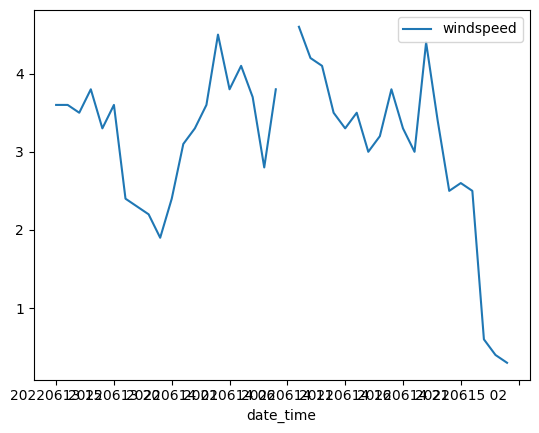

In [36]:
train.iloc[16643-20:16643+20, :].plot(x='date_time', y='windspeed')

In [37]:
#근처 값으로 사용
train['windspeed']= train.windspeed.interpolate()
train['humidity']= train.humidity.interpolate()

## Datetime 분리

In [38]:
train['date_time'] = pd.to_datetime(train['date_time'], format='%Y%m%d %H')

# date time feature 생성
train['hour'] = train['date_time'].dt.hour
train['day'] = train['date_time'].dt.day
train['month'] = train['date_time'].dt.month
train['day_of_week'] = train['date_time'].dt.dayofweek #요일


test['date_time'] = pd.to_datetime(test['date_time'], format='%Y%m%d %H')

# date time feature 생성
test['hour'] = test['date_time'].dt.hour
test['day'] = test['date_time'].dt.day
test['month'] = test['date_time'].dt.month
test['day_of_week'] = test['date_time'].dt.dayofweek #요일

In [39]:
train['date_time'].unique()

<DatetimeArray>
['2022-06-01 00:00:00', '2022-06-01 01:00:00', '2022-06-01 02:00:00',
 '2022-06-01 03:00:00', '2022-06-01 04:00:00', '2022-06-01 05:00:00',
 '2022-06-01 06:00:00', '2022-06-01 07:00:00', '2022-06-01 08:00:00',
 '2022-06-01 09:00:00',
 ...
 '2022-08-24 14:00:00', '2022-08-24 15:00:00', '2022-08-24 16:00:00',
 '2022-08-24 17:00:00', '2022-08-24 18:00:00', '2022-08-24 19:00:00',
 '2022-08-24 20:00:00', '2022-08-24 21:00:00', '2022-08-24 22:00:00',
 '2022-08-24 23:00:00']
Length: 2040, dtype: datetime64[ns]

In [40]:
# 유형별로 요일에 따른 전력 패턴이 있기 때문에 시간 분리가 중요하다고 언급함

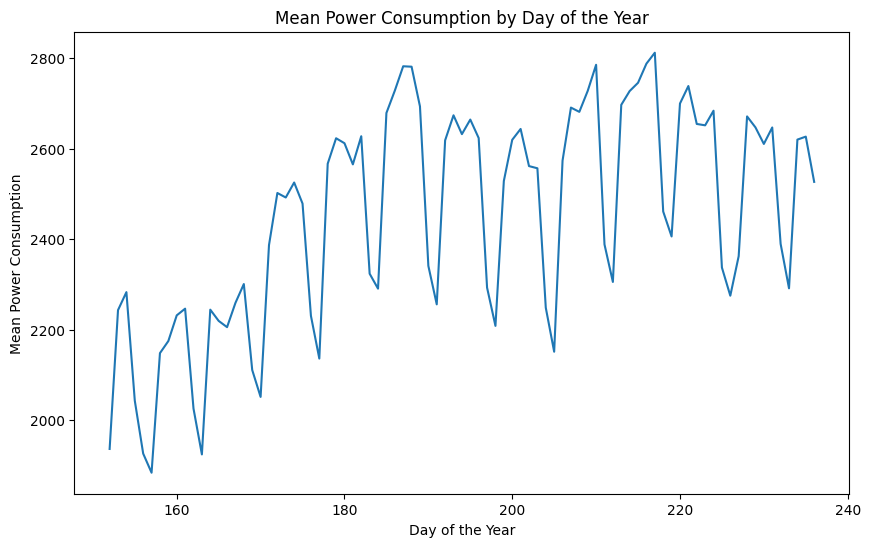

In [41]:
train['day_of_year'] = train['date_time'].dt.dayofyear
mean_power_by_day_of_year = train.groupby('day_of_year')['power_consumption'].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=mean_power_by_day_of_year.index, y=mean_power_by_day_of_year.values)
plt.title('Mean Power Consumption by Day of the Year')
plt.xlabel('Day of the Year')
plt.ylabel('Mean Power Consumption')
plt.show()

In [42]:
test['day'].unique()

array([25, 26, 27, 28, 29, 30, 31], dtype=int32)

In [43]:
train['month'].unique()

array([6, 7, 8], dtype=int32)

<Axes: xlabel='month'>

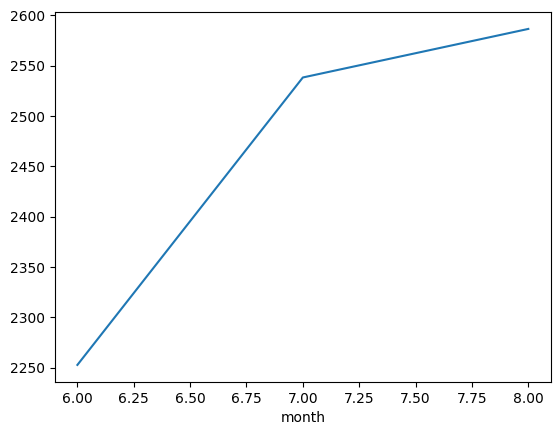

In [44]:
# 년기준 월평균 소비전력
mean_power_by_month = train.groupby('month')['power_consumption'].mean()
mean_power_by_month.plot()

<Axes: xlabel='hour'>

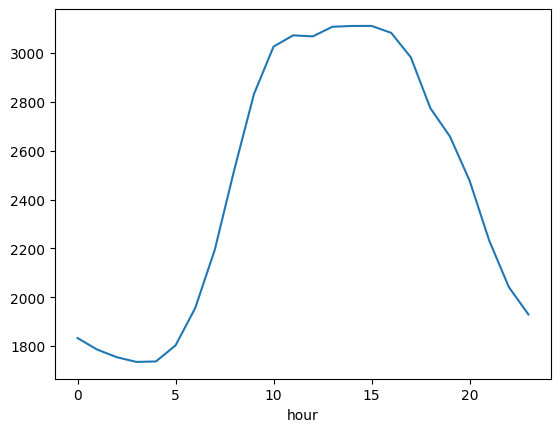

In [45]:
# 일기준 시간 평균 소비전력
mean_power_by_hour = train.groupby('hour')['power_consumption'].mean()
mean_power_by_hour.plot()


In [46]:
train.loc[:,'hour':'day_of_week']

,hour,day,month,day_of_week
0,0,1,6,2
1,1,1,6,2
2,2,1,6,2
3,3,1,6,2
4,4,1,6,2
...,...,...,...,...
203995,19,24,8,2
203996,20,24,8,2
203997,21,24,8,2
203998,22,24,8,2


## Feature Engineering

### 평균기온, 최대기온 변수

In [47]:
def calculate_day_values(dataframe, target_column, output_column, aggregation_func):
    result_dict = {}

    grouped_temp = dataframe.groupby(['building_number', 'month', 'day'])[target_column].agg(aggregation_func)

    for (building, month, day), value in grouped_temp.items():
        result_dict.setdefault(building, {}).setdefault(month, {})[day] = value

    dataframe[output_column] = [
        result_dict.get(row['building_number'], {}).get(row['month'], {}).get(row['day'], None)
        for _, row in dataframe.iterrows()
    ]


train['day_max_temperature'] = 0.0
train['day_mean_temperature'] = 0.0

calculate_day_values(train, 'temperature', 'day_max_temperature', 'max')
calculate_day_values(train, 'temperature', 'day_mean_temperature', 'mean')
calculate_day_values(train, 'temperature', 'day_min_temperature', 'min')

train['day_temperature_range'] = train['day_max_temperature'] - train['day_min_temperature']

calculate_day_values(test, 'temperature', 'day_max_temperature', 'max')
calculate_day_values(test, 'temperature', 'day_mean_temperature', 'mean')
calculate_day_values(test, 'temperature', 'day_min_temperature', 'min')

test['day_temperature_range'] = test['day_max_temperature'] - test['day_min_temperature']


In [48]:
#해당 출력 결과물 살펴보면 일일 시간별 최대온도, 평균온도 최소온도 범위값들이 다 담겨있음
# 온도에 대해서도 이런식으로 피쳐 엔지니어링이 가능하다는걸 알게됨

train.loc[:, 'day_max_temperature':'day_temperature_range']

,day_max_temperature,day_mean_temperature,day_min_temperature,day_temperature_range
0,28.4,22.266667,16.3,12.1
1,28.4,22.266667,16.3,12.1
2,28.4,22.266667,16.3,12.1
3,28.4,22.266667,16.3,12.1
4,28.4,22.266667,16.3,12.1
...,...,...,...,...
203995,26.0,22.958333,20.7,5.3
203996,26.0,22.958333,20.7,5.3
203997,26.0,22.958333,20.7,5.3
203998,26.0,22.958333,20.7,5.3


# Outlier drop

In [49]:
'''
아래처럼 보이는 예시의 이상치들의 row를 제거하는 방법을 택함

1th 이상치 처리
다른 방법들중 온도에 대한 이상치를제거하기위해서 이동평균데이터를 추가로 넣은것도있음
4일 7일 온도 이동평균 모델을 따로 학습시켜서 앙상블 기법을 적용하는 예시도 있음

  -> 이거보고서 그냥 전력 소비량에 대해서도 추세선을 적용해서 해봐도 되지 않을까?라는 생각이 들었음.
'''


'\n아래처럼 보이는 예시의 이상치들의 row를 제거하는 방법을 택함\n\n1th 이상치 처리\n다른 방법들중 온도에 대한 이상치를제거하기위해서 이동평균데이터를 추가로 넣은것도있음\n4일 7일 온도 이동평균 모델을 따로 학습시켜서 앙상블 기법을 적용하는 예시도 있음\n\n  -> 이거보고서 그냥 전력 소비량에 대해서도 추세선을 적용해서 해봐도 되지 않을까?라는 생각이 들었음.\n'

<Axes: >

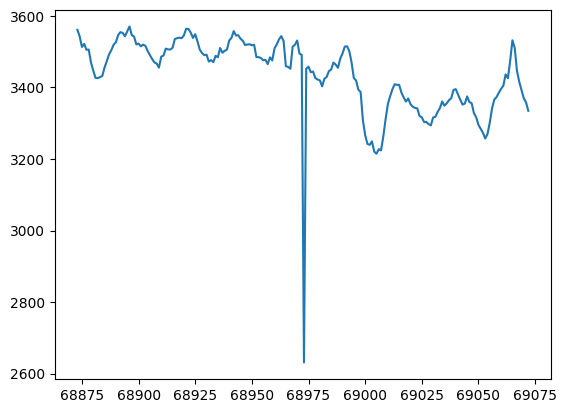

In [50]:
outlier_list = [68973,71013,112384,123132,150739,150740,150741,150742,
                150883,150884,150885,150886,138904,193120,193121,152393]

train.iloc[outlier_list[0]-100:outlier_list[0]+100,:]['power_consumption'].plot()

In [51]:
train.iloc[outlier_list[0]-100:outlier_list[0]+100,:]

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_utility,ess_utility,hour,day,month,day_of_week,day_of_year,day_max_temperature,day_mean_temperature,day_min_temperature,day_temperature_range
68873,34,2022-08-04 17:00:00,32.1,NaN,3.2,67.0,0.8,1.50,3561.12,Data Center,10665.0,9402.0,-,-,-,0,0,17,4,8,3,216,32.5,28.895833,26.1,6.4
68874,34,2022-08-04 18:00:00,31.3,NaN,3.0,70.0,0.8,0.82,3542.76,Data Center,10665.0,9402.0,-,-,-,0,0,18,4,8,3,216,32.5,28.895833,26.1,6.4
68875,34,2022-08-04 19:00:00,30.0,NaN,3.2,72.0,0.7,0.41,3513.24,Data Center,10665.0,9402.0,-,-,-,0,0,19,4,8,3,216,32.5,28.895833,26.1,6.4
68876,34,2022-08-04 20:00:00,29.0,NaN,2.6,76.0,0.0,0.03,3521.88,Data Center,10665.0,9402.0,-,-,-,0,0,20,4,8,3,216,32.5,28.895833,26.1,6.4
68877,34,2022-08-04 21:00:00,28.4,NaN,2.6,78.0,NaN,NaN,3505.32,Data Center,10665.0,9402.0,-,-,-,0,0,21,4,8,3,216,32.5,28.895833,26.1,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69068,34,2022-08-12 20:00:00,27.8,NaN,2.8,70.0,0.0,0.04,3416.04,Data Center,10665.0,9402.0,-,-,-,0,0,20,12,8,4,224,32.4,26.904167,23.0,9.4
69069,34,2022-08-12 21:00:00,27.2,NaN,1.4,72.0,NaN,NaN,3393.00,Data Center,10665.0,9402.0,-,-,-,0,0,21,12,8,4,224,32.4,26.904167,23.0,9.4
69070,34,2022-08-12 22:00:00,26.5,NaN,1.2,75.0,NaN,NaN,3369.60,Data Center,10665.0,9402.0,-,-,-,0,0,22,12,8,4,224,32.4,26.904167,23.0,9.4
69071,34,2022-08-12 23:00:00,26.0,NaN,1.4,76.0,NaN,NaN,3358.44,Data Center,10665.0,9402.0,-,-,-,0,0,23,12,8,4,224,32.4,26.904167,23.0,9.4


In [52]:
train.iloc[outlier_list[1]-100:outlier_list[1]+100,:]

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_utility,ess_utility,hour,day,month,day_of_week,day_of_year,day_max_temperature,day_mean_temperature,day_min_temperature,day_temperature_range
70913,35,2022-08-04 17:00:00,32.1,NaN,3.2,67.0,0.8,1.50,2263.2,Data Center,9736.0,6070.0,-,-,-,0,0,17,4,8,3,216,32.5,28.895833,26.1,6.4
70914,35,2022-08-04 18:00:00,31.3,NaN,3.0,70.0,0.8,0.82,2248.5,Data Center,9736.0,6070.0,-,-,-,0,0,18,4,8,3,216,32.5,28.895833,26.1,6.4
70915,35,2022-08-04 19:00:00,30.0,NaN,3.2,72.0,0.7,0.41,2232.9,Data Center,9736.0,6070.0,-,-,-,0,0,19,4,8,3,216,32.5,28.895833,26.1,6.4
70916,35,2022-08-04 20:00:00,29.0,NaN,2.6,76.0,0.0,0.03,2220.3,Data Center,9736.0,6070.0,-,-,-,0,0,20,4,8,3,216,32.5,28.895833,26.1,6.4
70917,35,2022-08-04 21:00:00,28.4,NaN,2.6,78.0,NaN,NaN,2217.6,Data Center,9736.0,6070.0,-,-,-,0,0,21,4,8,3,216,32.5,28.895833,26.1,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71108,35,2022-08-12 20:00:00,27.8,NaN,2.8,70.0,0.0,0.04,2206.5,Data Center,9736.0,6070.0,-,-,-,0,0,20,12,8,4,224,32.4,26.904167,23.0,9.4
71109,35,2022-08-12 21:00:00,27.2,NaN,1.4,72.0,NaN,NaN,2195.1,Data Center,9736.0,6070.0,-,-,-,0,0,21,12,8,4,224,32.4,26.904167,23.0,9.4
71110,35,2022-08-12 22:00:00,26.5,NaN,1.2,75.0,NaN,NaN,2186.4,Data Center,9736.0,6070.0,-,-,-,0,0,22,12,8,4,224,32.4,26.904167,23.0,9.4
71111,35,2022-08-12 23:00:00,26.0,NaN,1.4,76.0,NaN,NaN,2172.6,Data Center,9736.0,6070.0,-,-,-,0,0,23,12,8,4,224,32.4,26.904167,23.0,9.4


<Axes: >

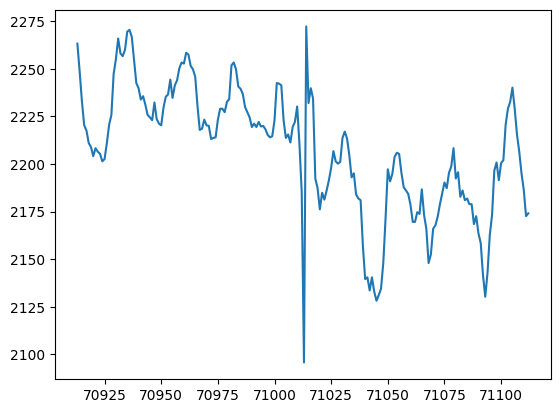

In [53]:
train.iloc[outlier_list[1]-100:outlier_list[1]+100,:]['power_consumption'].plot()

In [54]:
#이 부근에서 이상치가 발견된거고 row값을 없앰
outlier_list = [68973,71013,112384,123132,150739,150740,150741,150742,
                150883,150884,150885,150886,138904,193120,193121,152393]

train.drop(outlier_list, axis=0,inplace=True)

# 임시 휴무 추측 데이터 drop

In [55]:
#기타 빌딩
train[ (train['building_number']==2) & (train['date_time'] == '2022-06-17')]

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_utility,ess_utility,hour,day,month,day_of_week,day_of_year,day_max_temperature,day_mean_temperature,day_min_temperature,day_temperature_range
2424,2,2022-06-17,18.7,NaN,1.3,80.0,NaN,NaN,1223.28,Other Buildings,122233.47,99000.0,-,-,-,0,0,0,17,6,4,168,27.9,22.25,16.7,11.2


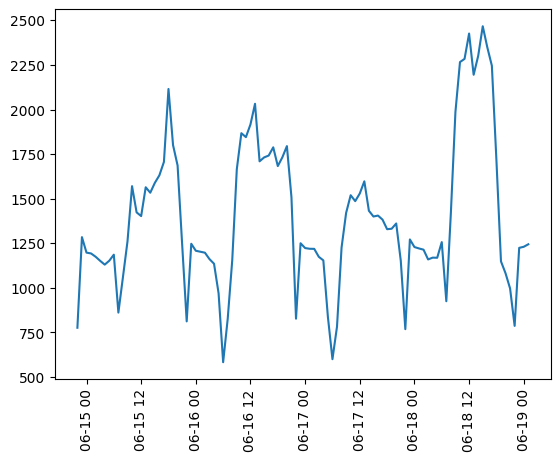

In [56]:
plt.plot(train.iloc[2424-50:2424+50,:]['date_time'],train.iloc[2424-50:2424+50,:]['power_consumption'])
plt.xticks(rotation=90)
plt.show()

In [57]:
department_df = train[ (train['building_number']==41)]
target_date = '2022-06-27'
filtered_df = department_df[department_df['date_time'].dt.strftime('%Y-%m-%d') == target_date]
filtered_df

,building_number,date_time,temperature,rainfall,windspeed,humidity,sunshine,solar_radiation,power_consumption,building_type,total_area,cooling_area,solar_power_capacity,ess_capacity,pcs_capacity,solar_power_utility,ess_utility,hour,day,month,day_of_week,day_of_year,day_max_temperature,day_mean_temperature,day_min_temperature,day_temperature_range
82224,41,2022-06-27 00:00:00,26.9,0.0,2.3,80.0,0.0,0.00,1306.8,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,0,27,6,0,178,28.0,26.6875,25.4,2.6
82225,41,2022-06-27 01:00:00,26.6,0.2,2.2,83.0,0.0,0.00,1073.4,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,1,27,6,0,178,28.0,26.6875,25.4,2.6
82226,41,2022-06-27 02:00:00,26.2,0.4,2.1,87.0,0.0,0.00,1046.4,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,2,27,6,0,178,28.0,26.6875,25.4,2.6
82227,41,2022-06-27 03:00:00,26.0,0.0,1.9,86.0,0.0,0.00,991.8,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,3,27,6,0,178,28.0,26.6875,25.4,2.6
82228,41,2022-06-27 04:00:00,25.8,0.4,0.5,89.0,0.0,0.00,936.0,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,4,27,6,0,178,28.0,26.6875,25.4,2.6
82229,41,2022-06-27 05:00:00,25.4,0.2,0.8,90.0,0.0,0.00,940.2,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,5,27,6,0,178,28.0,26.6875,25.4,2.6
82230,41,2022-06-27 06:00:00,25.5,0.0,1.0,89.0,0.0,0.00,981.0,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,6,27,6,0,178,28.0,26.6875,25.4,2.6
82231,41,2022-06-27 07:00:00,25.7,0.0,1.1,89.0,0.0,0.10,1280.4,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,7,27,6,0,178,28.0,26.6875,25.4,2.6
82232,41,2022-06-27 08:00:00,26.2,0.0,0.8,87.0,0.0,0.29,1803.6,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,8,27,6,0,178,28.0,26.6875,25.4,2.6
82233,41,2022-06-27 09:00:00,26.8,0.0,2.2,83.0,0.0,0.40,2023.8,Department Store and Outlet,161950.4,60579.45,-,-,-,0,0,9,27,6,0,178,28.0,26.6875,25.4,2.6


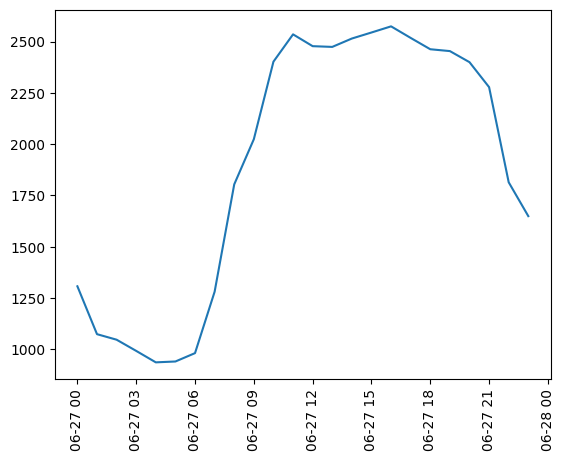

In [58]:
plt.plot(filtered_df['date_time'],filtered_df['power_consumption'])
plt.xticks(rotation=90)
plt.show()

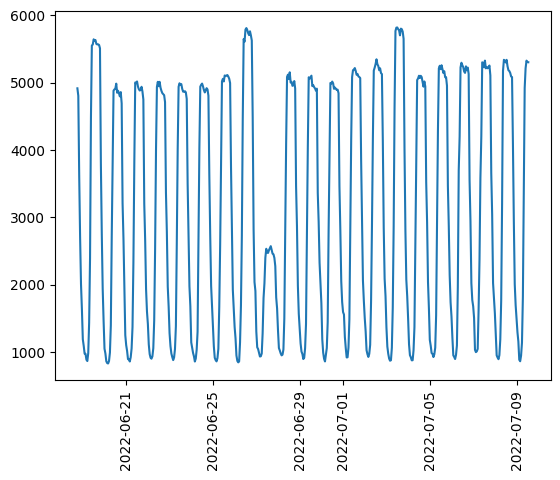

In [59]:
#train.iloc[73896-100:73896+100, :]['power_consumption']
plt.plot(train.iloc[82224-200:82224+300, :]['date_time'],train.iloc[82224-200:82224+300, :]['power_consumption'])
plt.xticks(rotation=90)
plt.show()


In [60]:
'''
백화점 데이터를 보면 저날만 푹 들어간것을 볼 수 있음 -> 이때 데이터를 그냥 지우는것도 제너럴한 상황을 파악할 수 있는 좋은 판단이었을것
'''

'\n백화점 데이터를 보면 저날만 푹 들어간것을 볼 수 있음 -> 이때 데이터를 그냥 지우는것도 제너럴한 상황을 파악할 수 있는 좋은 판단이었을것\n'

In [163]:
temp_hol = {2 : ['2022-06-17'],
    5 : ['2022-07-25','2022-08-02','2022-08-09','2022-08-16'],
    11 : ['2022-06-17'], 12 : ['2022-07-02'], 17 : ['2022-06-18','2022-07-25'],
    21 : ['2022-07-01','2022-07-03','2022-07-17','2022-07-30'],
    37 : ['2022-06-20','2022-07-11','2022-08-08'],
    38 : ['2022-06-13','2022-07-25','2022-08-01'],
    39 : ['2022-07-18','2022-08-08'],
    40 : ['2022-06-20','2022-07-18','2022-08-08'],
    41 : ['2022-06-27','2022-07-25','2022-08-08'],
    42 : ['2022-06-13','2022-07-11','2022-08-22'],
    54 : ['2022-08-16','2022-08-17'],74 : ['2022-06-03'],
    75 : ['2022-06-15','2022-06-17','2022-06-20','2022-06-21'],
    86 : ['2022-06-10','2022-08-10'],
    89 : ['2022-07-09'], 91 : ['2022-06-13','2022-07-11','2022-08-22','2022-06-08'], 92 : ['2022-07-30']}


mask = train.apply(lambda x: x['building_number'] in temp_hol and str(x['date_time'])[:10] in temp_hol[x['building_number']], axis=1)

train.drop(train[mask].index, axis=0, inplace=True)

train.reset_index(drop=True, inplace=True)

### 공휴일변수

* 시간 개념이 중요한 이유는 날짜 중 휴무인지 아닌지에 따라서 전력 소비량이 건물마다 달라지기떄문인듯. (가정집이나 회사)
* 그치만 백화점이나 대형마트는 휴일에도 진행하기에 대형마트 휴무요일변수를 따로 적용해주어야함.




In [ ]:
holi_weekday = ['2022-06-01', '2022-06-06', '2022-08-15']

train['holiday'] = np.where((train.day_of_week >= 5) | (train.date_time.dt.strftime('%Y-%m-%d').isin(holi_weekday)), 1, 0)
test['holiday'] = np.where((test.day_of_week >= 5) | (test.date_time.dt.strftime('%Y-%m-%d').isin(holi_weekday)), 1, 0)

### 대형마트 휴무일요일 변수

In [ ]:
holi_sun = ['2022-06-12', '2022-06-26', '2022-07-10', '2022-07-24', '2022-08-14', '2022-08-28']

train['Sunday_holiday'] = np.where((train.day_of_week == 6) & (train.date_time.dt.strftime('%Y-%m-%d').isin(holi_sun)), 1, 0)
test['Sunday_holiday'] = np.where((test.day_of_week == 6) & (test.date_time.dt.strftime('%Y-%m-%d').isin(holi_sun)), 1, 0)

### 시간변수 푸리에변환

* 이건 되게 특이한 변환인데, 푸리에 변환을 적용하면 시간이나 어떤 패턴이 있는 전력데이터를 주기성이 있는 데이터로 변환이 가능해짐
* 예를들어서 0시와 23시는 가까운데 distance로 보면 먼 숫자이다. 퓨리에 변환을 적용해서 이를 보여줌


In [ ]:
#시간
train['sin_hour'] = np.sin(2 * np.pi * train['hour']/23.0)
train['cos_hour'] = np.cos(2 * np.pi * train['hour']/23.0)
test['sin_hour'] = np.sin(2 * np.pi * test['hour']/23.0)
test['cos_hour'] = np.cos(2 * np.pi * test['hour']/23.0)

#날짜
train['sin_date'] = -np.sin(2 * np.pi * (train['month']+train['day']/31)/12)
train['cos_date'] = -np.cos(2 * np.pi * (train['month']+train['day']/31)/12)
test['sin_date'] = -np.sin(2 * np.pi * (test['month']+test['day']/31)/12)
test['cos_date'] = -np.cos(2 * np.pi * (test['month']+test['day']/31)/12)

#월
train['sin_month'] = -np.sin(2 * np.pi * train['month']/12.0)
train['cos_month'] = -np.cos(2 * np.pi * train['month']/12.0)
test['sin_month'] = -np.sin(2 * np.pi * test['month']/12.0)
test['cos_month'] = -np.cos(2 * np.pi * test['month']/12.0)

#요일
train['sin_dayofweek'] = -np.sin(2 * np.pi * (train['day_of_week']+1)/7.0)
train['cos_dayofweek'] = -np.cos(2 * np.pi * (train['day_of_week']+1)/7.0)
test['sin_dayofweek'] = -np.sin(2 * np.pi * (test['day_of_week']+1)/7.0)
test['cos_dayofweek'] = -np.cos(2 * np.pi * (test['day_of_week']+1)/7.0)

### CDH(냉방도시) 변수

* CDH 지수를 도입하는 이유는 여름철 전력 사용에 대해서 좀 더 밀접한 피쳐를 만들기 위함입니다.
* 온도 피쳐를 직접 입력하는 것보다 여름철 기온이 상승할때를 두고 판단하는 피쳐입니다. 전력 소모량이 많다는 것을 직접적으로 모델에 입력하는것이 더 성능 향상에 도움이 될것이라는 판단에 입력한 피쳐라고 생각합니다.



In [ ]:
def CDH(xs):
    cumsum = np.cumsum(xs - 26)
    return np.concatenate((cumsum[:11], cumsum[11:] - cumsum[:-11]))

def calculate_and_add_cdh(dataframe):
    cdhs = []
    for i in range(1, 101):
        temp = dataframe[dataframe['building_number'] == i]['temperature'].values
        cdh = CDH(temp)
        cdhs.append(cdh)
    return np.concatenate(cdhs)

train['CDH'] = calculate_and_add_cdh(train)
test['CDH'] = calculate_and_add_cdh(test)

### THI(불쾌지수) 변수

* 불쾌지수는 주가 예측시에도 했던 것. 온도에 따른 인간의 감정을 범주형 데이터로 생성. 그리고 각 범주에 따라서 투자 패턴이 달라질 것으로 분석. 하지만 큰 영향은 없었음
* 불쾌지수는 에어컨과 큰 상관관계가 있는 데이터로 파악됨. 따라서 이런 데이터를 입력 데이터로 사용하는 것은 큰 유의미가 있을 것으로 예상된다.
* corr heatmap도 보면 좋을듯

In [ ]:
train['THI'] = 9/5*train['temperature'] - 0.55*(1-train['humidity']/100)*(9/5*train['humidity']-26)+32

test['THI'] = 9/5*test['temperature'] - 0.55*(1-test['humidity']/100)*(9/5*test['humidity']-26)+32

### WCT(체감온도) 변수

* 체감온도는 겨울철 냉난방에 큰 영향을 미치는 피쳐이기에 사용됨

In [ ]:
train['WCT'] = 13.12 + 0.6125*train['temperature'] - 11.37*(train['windspeed']**
                                                            0.16) + 0.3965*(train['windspeed']**0.16)*train['temperature']
test['WCT'] = 13.12 + 0.6125*test['temperature'] - 11.37*(test['windspeed']**
                                                            0.16) + 0.3965*(test['windspeed']**0.16)*test['temperature']

### 전력소비 통계량 변수

* 전력 소비 통계량 변수는 자주 사용하는 변수로 보임.
* 1th분석에서도 온도에 이상치 값이 많아서 이런 통계량 변수를 많이 사용함.

* 근데 이런 통계량에 대해서 주식에 사용되는 기술적 지표를 더 추가로 넣어서 사용하면 어떨까?라는 생각이 듬.


In [ ]:
# Calculate 'day_hour_mean'
power_mean = pd.pivot_table(train, values='power_consumption', index=['building_number', 'hour', 'day_of_week'], aggfunc=np.mean).reset_index()
power_mean.columns = ['building_number', 'hour', 'day_of_week', 'day_hour_mean']

# Calculate 'day_hour_std'
power_std = pd.pivot_table(train, values='power_consumption', index=['building_number', 'hour', 'day_of_week'], aggfunc=np.std).reset_index()
power_std.columns = ['building_number', 'hour', 'day_of_week', 'day_hour_std']

# Calculate 'hour_mean'
power_hour_mean = pd.pivot_table(train, values='power_consumption', index=['building_number', 'hour'], aggfunc=np.mean).reset_index()
power_hour_mean.columns = ['building_number', 'hour', 'hour_mean']

# Calculate 'hour_std'
power_hour_std = pd.pivot_table(train, values='power_consumption', index=['building_number', 'hour'], aggfunc=np.std).reset_index()
power_hour_std.columns = ['building_number', 'hour', 'hour_std']

# Merge calculated features to 'train' and 'test' dataframes
train = train.merge(power_mean, on=['building_number', 'hour', 'day_of_week'], how='left')
test = test.merge(power_mean, on=['building_number', 'hour', 'day_of_week'], how='left')

train = train.merge(power_std, on=['building_number', 'hour', 'day_of_week'], how='left')
test = test.merge(power_std, on=['building_number', 'hour', 'day_of_week'], how='left')

train = train.merge(power_hour_mean, on=['building_number', 'hour'], how='left')
test = test.merge(power_hour_mean, on=['building_number', 'hour'], how='left')

train = train.merge(power_hour_std, on=['building_number', 'hour'], how='left')
test = test.merge(power_hour_std, on=['building_number', 'hour'], how='left')

train = train.reset_index(drop=True)

# 모델링

## X,Y,test 선언

In [ ]:
X = train.drop(['solar_power_capacity', 'ess_capacity', 'pcs_capacity',
                'power_consumption','rainfall', 'sunshine', 'solar_radiation',
                'hour','day','month','day_of_week','date_time'],axis =1 )

Y = train[['building_type','power_consumption']]

test_X = test.drop(['solar_power_capacity', 'ess_capacity', 'pcs_capacity','rainfall',
                   'hour','month','day_of_week','day','date_time'], axis=1)

In [ ]:
type_list = []
for value in train.building_type.values:
    if value not in type_list:
        type_list.append(value)

## XGB 건물 유형별 단일모델

In [ ]:
xgb_best_params = pd.read_csv('5_07 xgb 파라미터.csv')
xgb_best_params['building_type'] = type_list
xgb_best_params.set_index('building_type',inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: '5_07 xgb 파라미터.csv'

In [ ]:
xgb_best_params

In [ ]:
kf = KFold(n_splits = 7,shuffle=True,random_state=RANDOM_SEED)
answer_df = pd.DataFrame(columns=['answer'])
pred_df = pd.DataFrame(columns=['pred'])



for i in type_list:

    x = X[(X.building_type == i)]
    y = Y[(Y.building_type == i)]
    X_test = test_X[test_X.building_type==i]

    x = pd.get_dummies(x, columns=['building_number'], drop_first=False)
    X_test = pd.get_dummies(X_test, columns=['building_number'], drop_first=False)

    x = x.drop(['building_type'],axis =1)
    X_test = X_test.drop(['building_type'],axis =1)
    y = y['power_consumption']
    x_columns = np.array(x.columns)
    x = np.array(x) ; y = np.array(y)

    j = 0
    xgb_fold_smape = []
    answer_list = []
    pred = pd.DataFrame(index = range(0,y.shape[0]), columns=['pred'])
    answer = pd.DataFrame(columns=['answer'])

    for train_index, valid_index in kf.split(x):
        j += 1



        X_train, X_valid = x[train_index], x[valid_index]
        Y_train, Y_valid = y[train_index], y[valid_index]
        Y_train = np.log(Y_train) ; Y_valid = np.log(Y_valid)


        evals = [(X_train,Y_train),(X_valid,Y_valid)]
        xgb_model = XGBRegressor(learning_rate = 0.05,n_estimators = 5000,
                             max_depth = int(xgb_best_params.loc[i]['max_depth']),
                             random_state = RANDOM_SEED,
                            subsample = xgb_best_params.loc[i]['subsample'],
                             colsample_bytree = xgb_best_params.loc[i]['colsample_bytree'],
                             min_child_weight = int(xgb_best_params.loc[i]['min_child_weight']),
                             objective=weighted_mse(xgb_best_params.loc[i]['alpha']))

        xgb_model.fit(X_train, Y_train, early_stopping_rounds = 100,
                       eval_metric = custom_smape, eval_set = evals, verbose = False)
        xgb_pred = xgb_model.predict(X_valid)
        xgb_pred = np.exp(xgb_pred)
        pred['pred'][valid_index] = xgb_pred
        xgb_smape = smape(np.exp(Y_valid),xgb_pred)
        xgb_answer = xgb_model.predict(X_test)
        answer_list.append(np.exp(xgb_answer))
        xgb_fold_smape.append(xgb_smape)


        if j == 7:
            sorted_idx = xgb_model.feature_importances_.argsort()
            plt.figure(figsize=(8,15))
            plt.barh(x_columns[sorted_idx],  xgb_model.feature_importances_[sorted_idx])
            plt.xlabel('%s model XGB Feature Importance'%(i))
            plt.show()


    type_answer = sum(answer_list) / len(answer_list)

    answer.answer = type_answer
    answer_df = pd.concat([answer_df,answer],ignore_index=True)
    pred_df = pd.concat([pred_df,pred],ignore_index=True)

    avg_smape = sum(xgb_fold_smape) / len(xgb_fold_smape)
    print('Building type = %s : XGBRegressor Model SMAPE : %.4f' %(i,avg_smape))


total_score = smape(Y.power_consumption,pred_df.pred)
print('Total SMAPE : %.4f'%(total_score))

## 정답파일 만들기

In [ ]:
answer = pd.read_csv('sample_submission.csv')

In [ ]:
answer.answer = answer_df.answer

In [ ]:
answer.to_csv('private_재현.csv',index = False)

In [ ]:
answer.head()